# Phase 3 — E-Commerce Customer Churn
## Notebook 01: Exploratory Data Analysis


In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Portable paths (works on any machine) ────────────────────────────────────
ROOT = os.path.dirname(os.path.abspath('__file__'))
DATA_RAW  = os.path.join(ROOT, '..', 'data', 'raw',  'E Commerce Dataset.xlsx')
DATA_PROC = os.path.join(ROOT, '..', 'data', 'processed')
FIG_DIR   = os.path.join(ROOT, '..', 'reports', 'figures')
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

%matplotlib inline
sns.set_theme(style='whitegrid')

In [2]:
# Load sheet index 1 (the data sheet)
df = pd.read_excel(DATA_RAW, sheet_name=1)
print('Shape:', df.shape)
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [4]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


## 1. Duplicates & Missing Values

In [5]:
print('Duplicates:', df.duplicated().sum())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Duplicates: 0

Missing values:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [6]:
# All missing columns are numerical → fill with mean
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f'  Filling {col} ({df[col].dtype}) with mean={df[col].mean():.2f}')
        df[col] = df[col].fillna(df[col].mean())   # assignment — works with Copy-on-Write

print('\nRemaining nulls:', df.isnull().sum().sum())

  Filling Tenure (float64) with mean=10.19
  Filling WarehouseToHome (float64) with mean=15.64
  Filling HourSpendOnApp (float64) with mean=2.93
  Filling OrderAmountHikeFromlastYear (float64) with mean=15.71
  Filling CouponUsed (float64) with mean=1.75
  Filling OrderCount (float64) with mean=3.01
  Filling DaySinceLastOrder (float64) with mean=4.54

Remaining nulls: 0


## 2. Churn Distribution

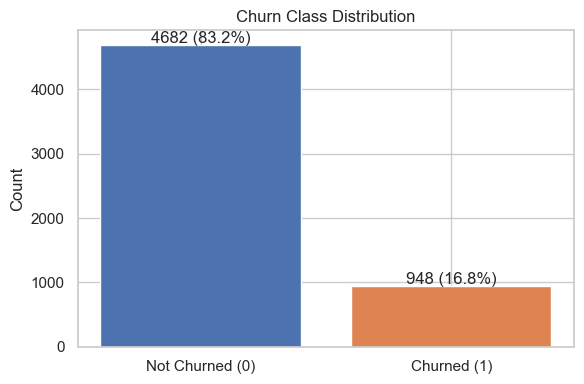

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()
ax.bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Count')
ax.set_title('Churn Class Distribution')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'churn_distribution.png'), dpi=150)
plt.show()

## 3. Numerical Features — Distribution by Churn

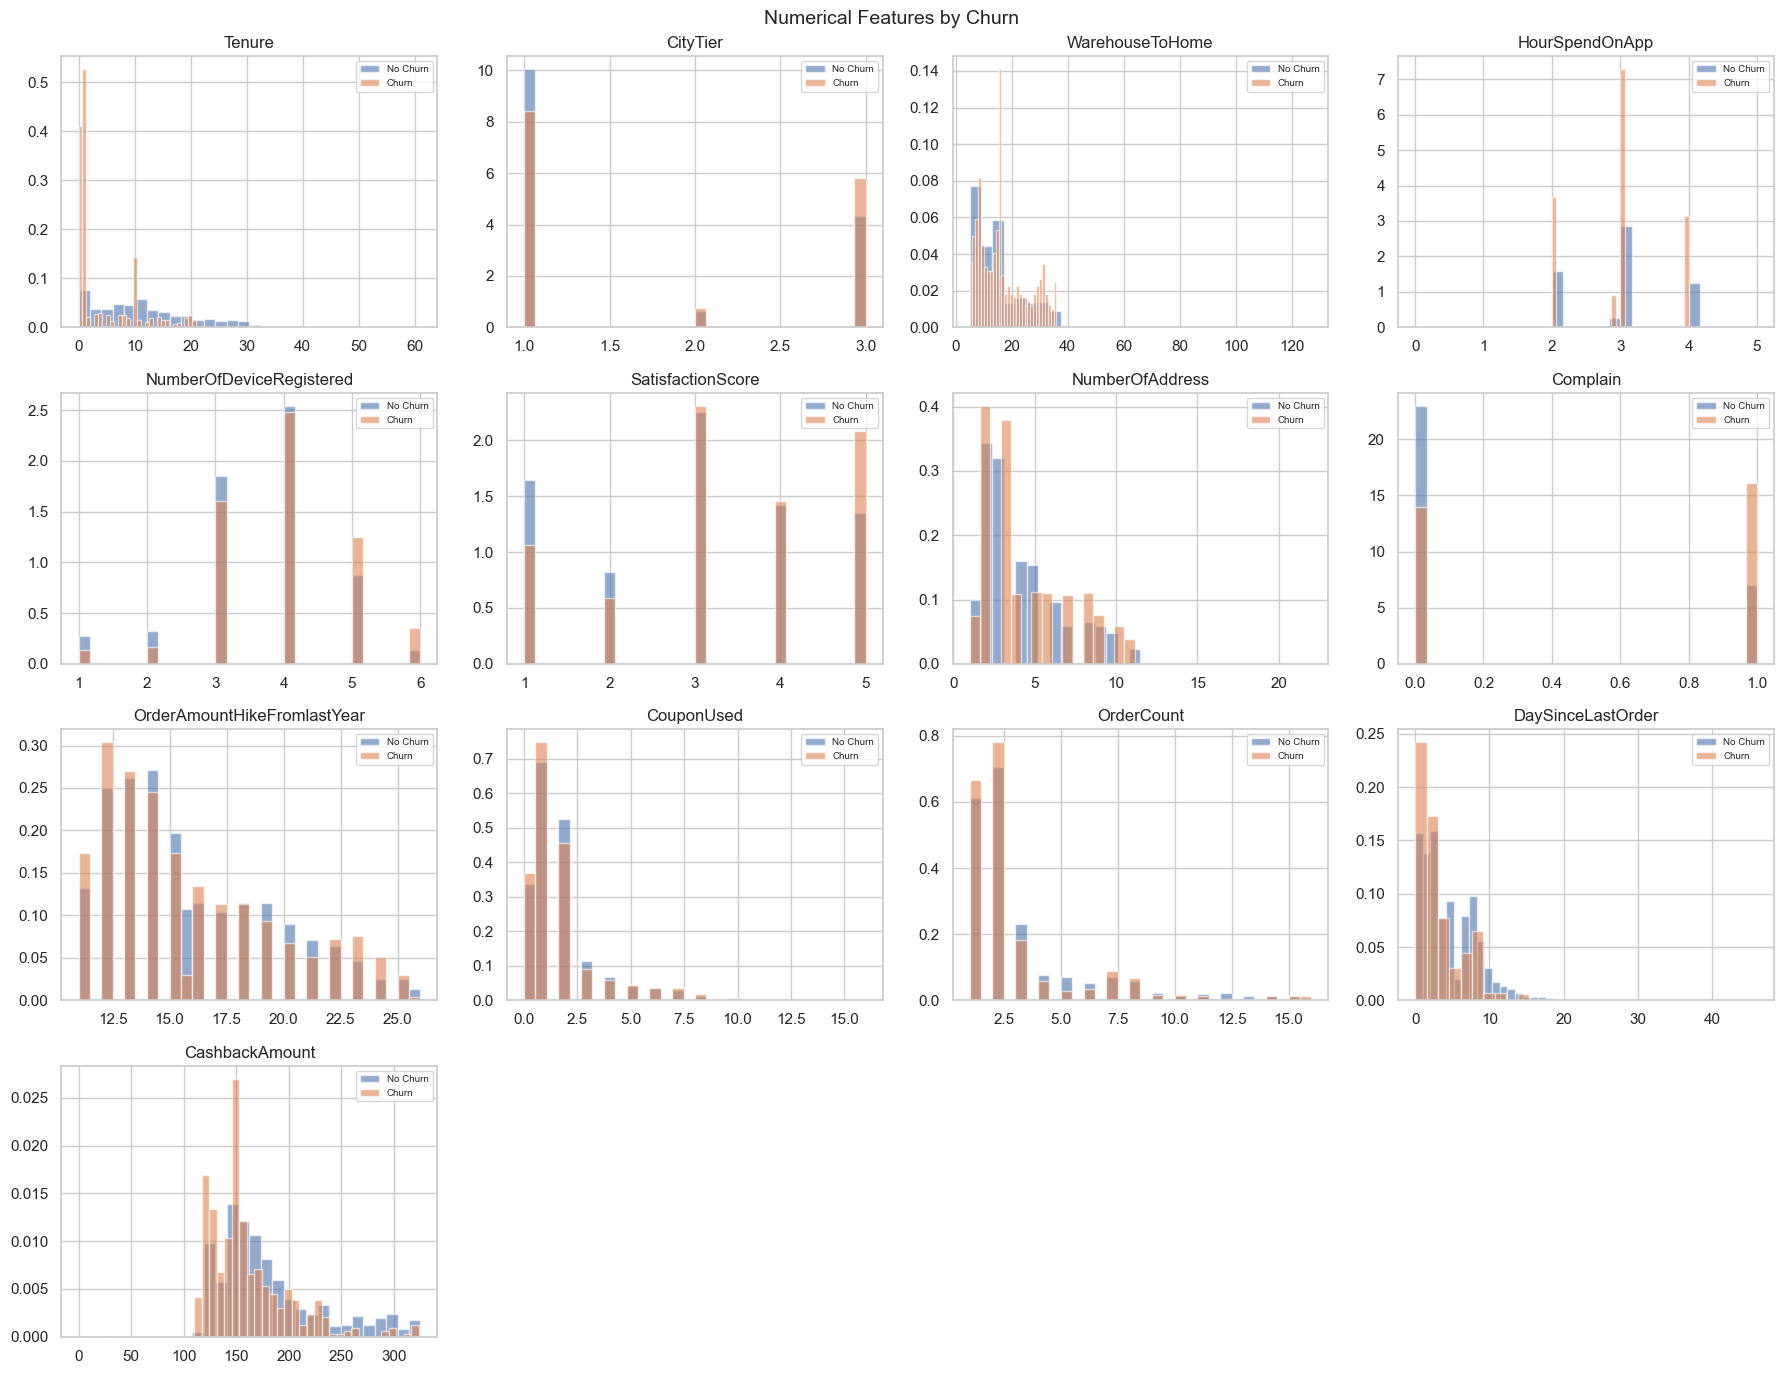

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['CustomerID', 'Churn']]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    for churn_val, label, color in [(0, 'No Churn', '#4C72B0'), (1, 'Churn', '#DD8452')]:
        axes[i].hist(df[df['Churn'] == churn_val][col], bins=30,
                     alpha=0.6, label=label, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

for j in range(len(num_cols[:16]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Churn', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'numerical_distributions.png'), dpi=150)
plt.show()

## 4. Categorical Features — Churn Rate

/var/folders/4b/0w0rsx895vd1lgwp5z1c6g640000gn/T/ipykernel_83662/64713359.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


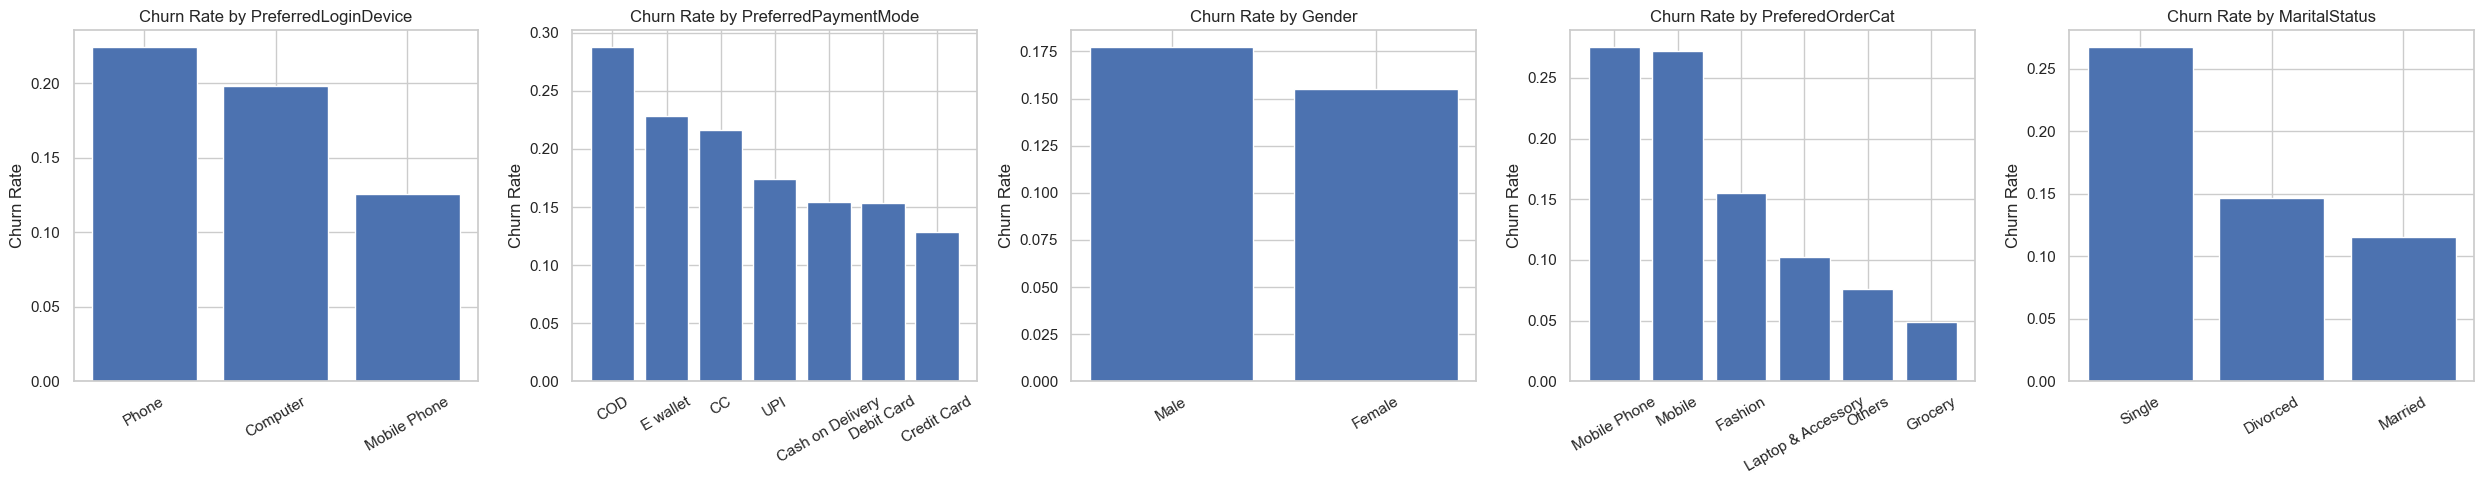

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    ax.bar(churn_rate.index, churn_rate.values, color='#4C72B0')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'categorical_churn_rates.png'), dpi=150)
plt.show()

## 5. Correlation Heatmap

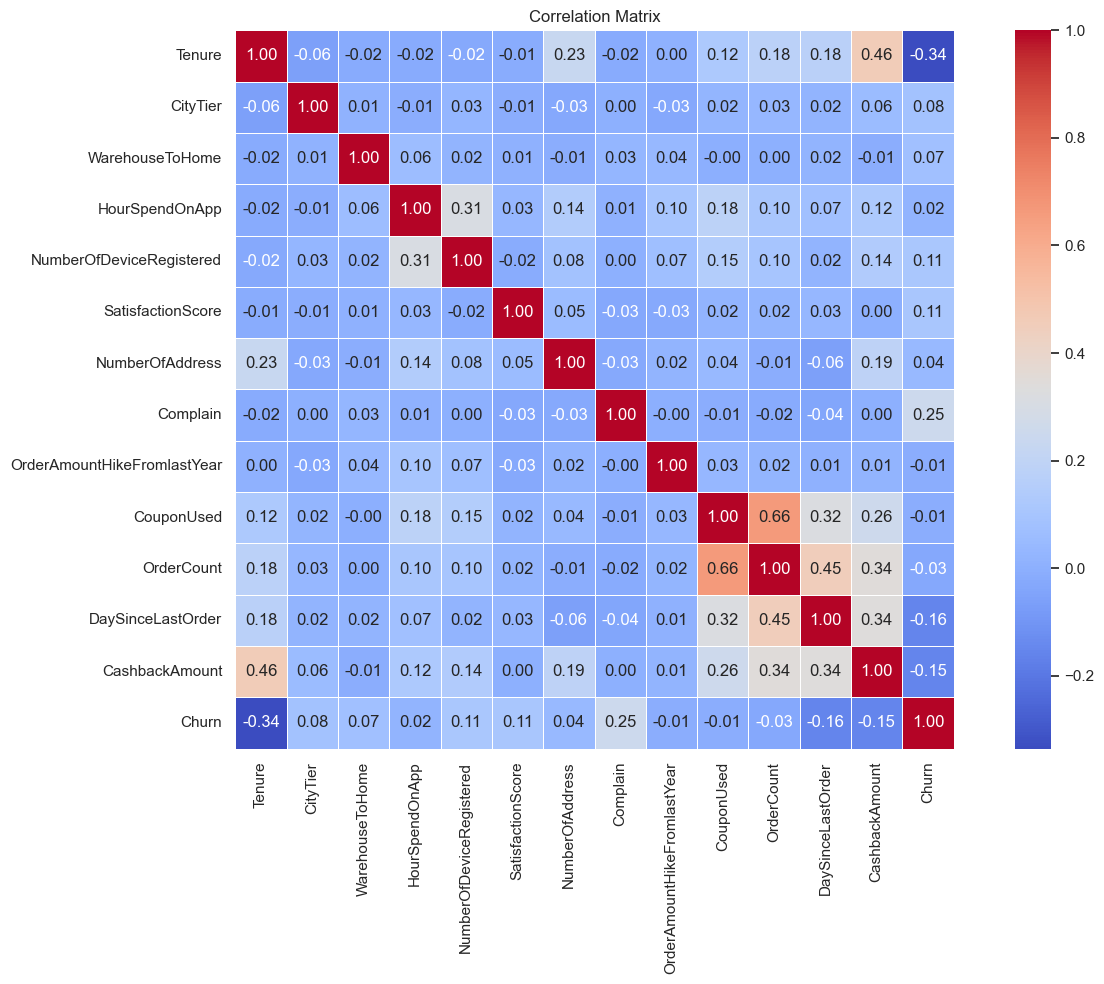

In [10]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols + ['Churn']].corr()
mask = corr.abs() < 0.05
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()

## 6. Save Cleaned Data

In [11]:
out_path = os.path.join(DATA_PROC, 'churn_cleaned.csv')
df.to_csv(out_path, index=False)
print('Saved cleaned data to:', out_path)
print('Shape:', df.shape)

Saved cleaned data to: /Users/abdullahnakhal/Desktop/noor/AI/Plan/e-commerce (Customer Churn Predecation)/notebooks/../data/processed/churn_cleaned.csv
Shape: (5630, 20)
